Superposition of sin waves to show that the inertial wave filtering can be specific to a single frequency, or if no specific frequency is selected, then no change is made to the signal.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
# dirPath = "C:/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)


####Import Ollie Tools MAC
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
/Users/olliejackson/Coding
Thesis plot settings applied


(0.0, 31.41592653589793)

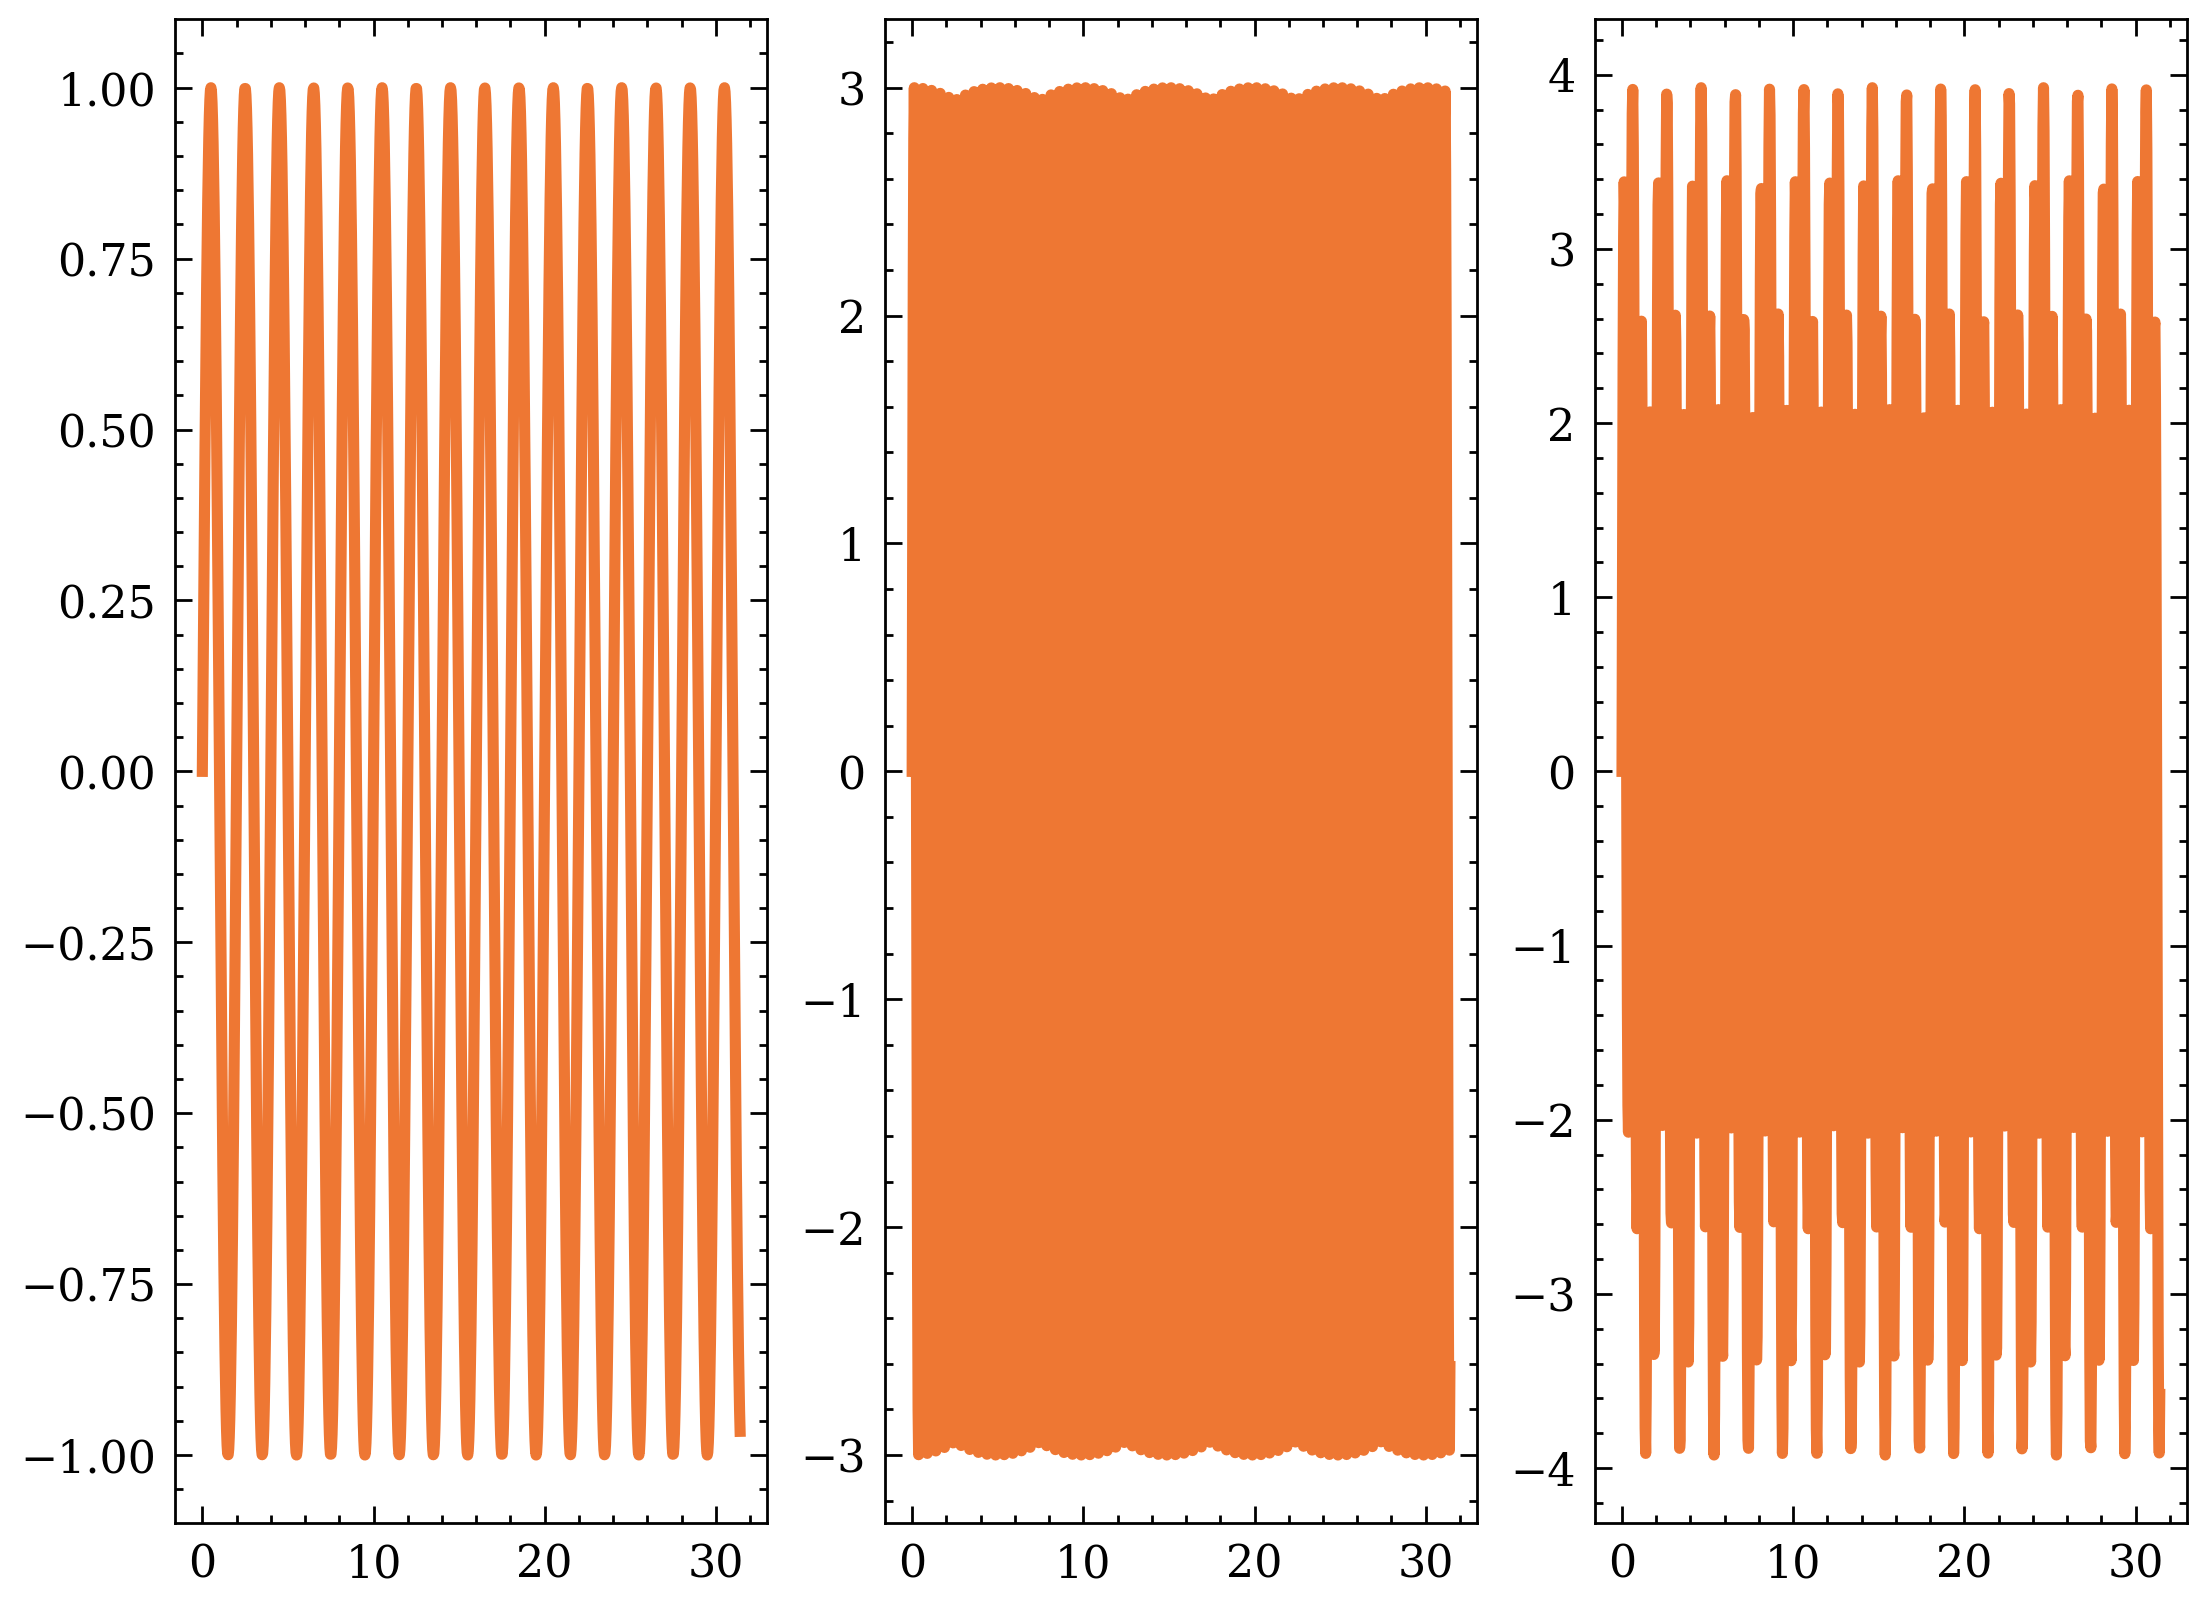

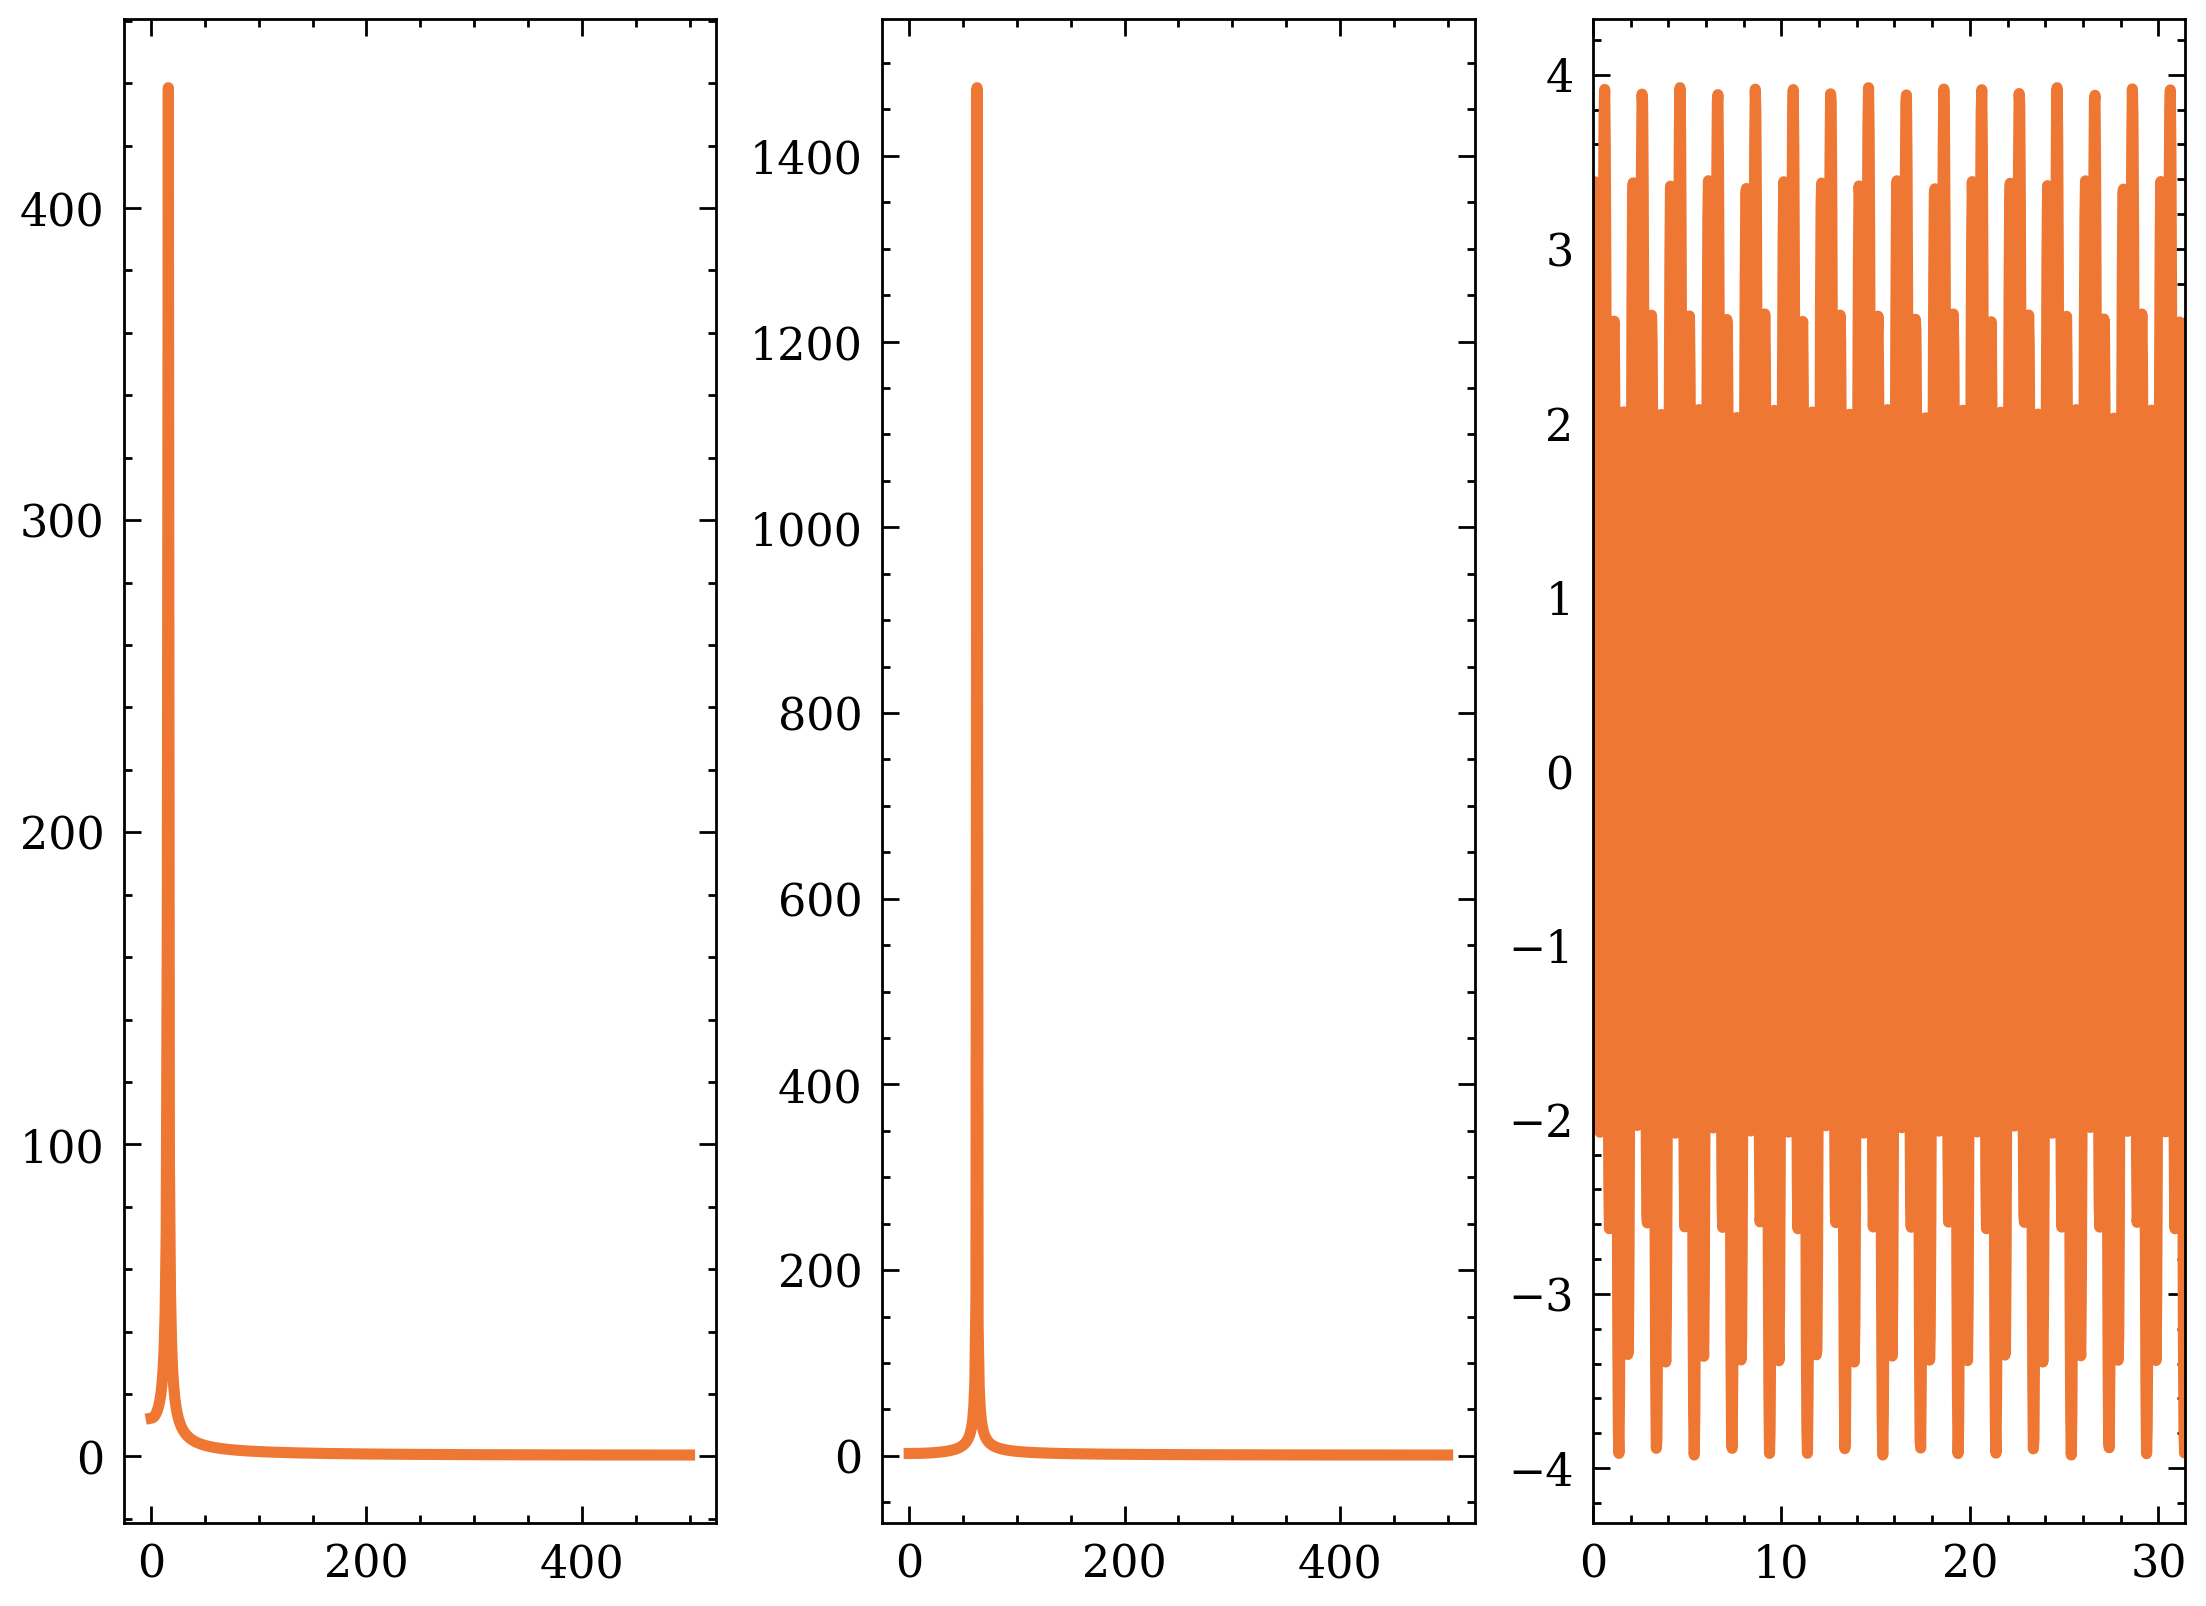

In [34]:
x = np.linspace(0, 10*np.pi, 1000)
s1 = np.sin(np.pi*x)
s2 = 3*np.sin(4*np.pi*x)


f1, ax = plt.subplots(1,3)
ax[0].plot(x, s1)
ax[1].plot(x, s2)
ax[2].plot(x, s1+s2)


fft1 = np.fft.rfft(s1)
fft2 = np.fft.rfft(s2)
recon = np.fft.irfft(fft1+fft2)

f2, ax2 = plt.subplots(1,3)
ax2[0].plot(np.abs(fft1))
ax2[1].plot(np.abs(fft2))
# ax2[2].plot(np.abs(fft1+fft2))
ax2[2].plot(x, recon)
plt.xlim(0, 10*np.pi)

Using the same IW filtering

In [42]:
forcedFreq = 4
fps = 100
rpm = np.pi
input_ang = 30

inputArray = np.array([s1, s2])

v_fluc = inputArray.copy()
v1 = np.mean(v_fluc, axis=0)
v_fluc -= v1

v_fluc = s1
if forcedFreq == 0:
    filtfreq = oj.FiltFreqCalc(input_ang,fps=fps,rpm=rpm)
else:
    filtfreq = forcedFreq

# thresh = 0.03
# thresh = 0.09
thresh = 0.1

v_FFT = oj.fft(v_fluc, axis=0)
FFTFreq = oj.fftfreq(v_fluc.shape[0], 1 / fps)
    
mask1 = np.where(np.logical_and(filtfreq-thresh<FFTFreq, filtfreq+thresh>FFTFreq))
mask2 = np.where(np.logical_and(-filtfreq-thresh<FFTFreq, -filtfreq+thresh>FFTFreq))
    
window1 = np.zeros_like(FFTFreq)
window1[mask1] = 1
width = np.sum(window1)
window1[mask1] = np.hanning(width)
    
window2 = np.zeros_like(FFTFreq)
window2[mask2] = 1
window2[mask2] = np.hanning(width)

windowT = window1 + window2

v_FFT = v_FFT*windowT[:, None, None] 
v = oj.ifft(v_FFT, axis=0)
v_postFFT = np.real(v)
